<a href="https://colab.research.google.com/github/chaeee01/3DGS-Character-Generation-Pipeline/blob/feature%2Fsam2-preprocess/SAM2_try6_260711.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##좀비 영상 배경 객체 분리 전체 코드_260707



#### [1] 구글 드라이브 연결

In [6]:
# 구글 드라이브와 코랩 컴퓨터를 연결하는 코드
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#### [2] SAM 2 오픈소스 다운로드 및 환경 설치

In [7]:
# 1. SAM 2 소스코드 다운로드 및 패키지 설치
!git clone https://github.com/facebookresearch/sam2.git
%cd sam2
!pip install -e .

# 2. 가중치(뇌 세포) 파일 저장할 폴더 만들고 다운로드
!mkdir -p checkpoints
!wget -P checkpoints/ https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_tiny.pt

# 3. 파이썬이 패키지를 즉시 인식할 수 있도록 시스템 경로 선언
import sys
import os
sys.path.append("/content/sam2")
sys.path.append("/content/sam2/sam2")

print("🎯 SAM 2 환경 설치 및 패키지 로드 완료!")

Cloning into 'sam2'...
remote: Enumerating objects: 1107, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 1107 (delta 10), reused 4 (delta 4), pack-reused 1093 (from 2)
Receiving objects: 100% (1107/1107), 134.85 MiB | 14.35 MiB/s, done.
Resolving deltas: 100% (385/385), done.
/content/sam2
Obtaining file:///content/sam2
  Installing build dependencies ... canceledERROR: Operation cancelled by user
--2026-07-11 07:09:34--  https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_tiny.pt
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 65.9.168.62, 65.9.168.4, 65.9.168.52, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|65.9.168.62|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 155906050 (149M) [application/vnd.snesdev-page-table]
Saving to: ‘checkpoints/sam2_hiera_tiny.pt’

sam2_hiera_tiny.pt  100%[===================>] 148.68M   301MB/s    in 0.5s    


#### [3] 프레임 쪼개기

In [ ]:
import os
import cv2
import torch
from sam2.build_sam import build_sam2_video_predictor

# 1. ⚠️ 구글 드라이브에 올려둔 영상 경로 (방금 복사한 경로를 붙여넣으세요)
video_path = "/content/drive/MyDrive/zombie_project/zombie_sample1.mp4"

# 2. 쪼개진 프레임들이 저장될 경로 (이것도 구글 드라이브로 지정하면 영구 저장됩니다!)
output_dir = "/content/drive/MyDrive/zombie_project/zombie_frames1"
os.makedirs(output_dir, exist_ok=True)

# 영상 읽기 및 프레임 쪼개기 작업 시작
cam = cv2.VideoCapture(video_path)
frame_idx = 0
while True:
    ret, frame = cam.read()
    if not ret:
        break
    # 파일명을 00000.jpg 형태로 저장
    cv2.imwrite(os.path.join(output_dir, f"{frame_idx:05d}.jpg"), frame)
    frame_idx += 1
cam.release()
print(f"총 {frame_idx}개의 좀비 비디오 프레임 추출 및 구글 드라이브 저장 완료!")

#### [4] 구글 드라이브의 프레임 불러오기 및 예측기(Predictor) 탑재

In [ ]:
'''
import torch
from sam2.build_sam import build_sam2_video_predictor

# ⚠️구글 드라이브의 폴더 경로
output_dir = "/content/drive/MyDrive/zombie_project/zombie_frames1"
'''
# 모델 설정 파일과 다운받은 가중치 매핑
model_cfg = "sam2_hiera_t.yaml"
sam2_checkpoint = "./checkpoints/sam2_hiera_tiny.pt"

# L4 GPU에 예측기 탑재 후 동영상 상태 초기화 (불러오기)
predictor = build_sam2_video_predictor(model_cfg, sam2_checkpoint)
inference_state = predictor.init_state(video_path=output_dir)

print("🎯 [성공] 구글 드라이브에 있던 좀비 프레임을 정상적으로 불러와 AI 엔진에 등록했습니다!")

#### [5] 0번 프레임 좌표 지정 (타겟 록온)
** 좌표 확인하는 셀 아래 추가

In [ ]:
import numpy as np

ann_frame_idx = 0  # 첫 번째 프레임
ann_obj_id = 1     # 좀비 오브젝트 ID 번호 (1번)

# 좀비가 있을 법한 가로/세로 픽셀 좌표 설정 (영상 중심부가 기본값)
points = np.array([[640, 360]], dtype=np.float32)
labels = np.array([1], dtype=np.int32)
# 1 = 전경(좀비), 0 = 배경

# 첫 프레임에 타겟 점 추가
_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=ann_frame_idx,
    obj_id=ann_obj_id,
    points=points,
    labels=labels,
)
print("🎯 0번 프레임 좀비 좌표 타겟팅 완료! 이제 달릴 준비가 되었습니다.")

#### [6] 전 프레임 추적 및 투명 배경 PNG 실시간 저장
SAM 2가 마스크를 한 장씩 딸 때마다, 원본 이미지에서 좀비 영역만 쏙 빼내어 배경이 투명한 PNG 시퀀스로 구글 드라이브의 zombie_output_pngs 폴더에 즉시 저장한다.

In [ ]:
from tqdm import tqdm

# 1. 최종 누끼 이미지들이 저장될 구글 드라이브 폴더 생성
save_dir = "/content/drive/MyDrive/zombie_project/zombie_output3_pngs"
os.makedirs(save_dir, exist_ok=True)

# 2. 아까 쪼개두었던 원본 프레임들이 있는 경로
frames_dir = "/content/drive/MyDrive/zombie_project/zombie_frames1"
frame_names = sorted([f for f in os.listdir(frames_dir) if f.endswith(".jpg")])

print("🚀 좀비 객체 추적 및 투명 배경 PNG 변환/저장 시작합니다...")

# 3. SAM 2 비디오 추적 루프 가동 (L4 GPU 가속)
# tqdm을 통해 1758장이 실시간으로 처리되는 진척도를 바(Bar)로 보여줍니다.
for out_frame_idx, out_obj_ids, out_mask_logits in tqdm(predictor.propagate_in_video(inference_state), total=len(frame_names)):

    # 현재 프레임의 원본 이미지 읽기
    frame_name = frame_names[out_frame_idx]
    img_path = os.path.join(frames_dir, frame_name)
    src_img = cv2.imread(img_path) # BGR 이미지

    h, w, _ = src_img.shape

    # 기본적으로 완전히 투명한 배경화면(알파채널 0) 생성 (BGRA)
    rgba_output = np.zeros((h, w, 4), dtype=np.uint8)

    for i, out_obj_id in enumerate(out_obj_ids):
        # AI가 찾아낸 좀비 마스크 (True/False 행렬)
        mask = (out_mask_logits[i] > 0.0).cpu().numpy().squeeze()

        # 좀비 영역에 해당하는 픽셀만 원본에서 복사하고, 알파 채널(불투명도)을 255로 설정
        rgba_output[mask, 0:3] = src_img[mask, 0:3] # BGR 복사
        rgba_output[mask, 3] = 255                  # 좀비 영역만 불투명하게

    # 구글 드라이브에 투명 PNG 파일로 저장 (파일명 포맷: zombie_00000.png)
    out_filename = f"zombie_{out_frame_idx:05d}.png"
    cv2.imwrite(os.path.join(save_dir, out_filename), rgba_output)

print(f"\n🎯 [대성공] 총 {len(frame_names)}장의 실사 좀비 누끼 에셋이 구글 드라이브 '{save_dir}' 폴더에 완벽하게 저장되었습니다!")

#### [7] PNG를 엮어서 배경이 투명하게 유지되는 고화질 좀비 비디오 파일 생성

In [8]:
#version1
from tqdm import tqdm

png_dir = "/content/drive/MyDrive/zombie_project/zombie_output3_pngs"
video_output_path = "/content/drive/MyDrive/zombie_project/zombie_isolated2.mp4"

images = sorted([img for img in os.listdir(png_dir) if img.endswith(".png")])

# 0번 이미지로 비디오 해상도 측정
sample_img = cv2.imread(os.path.join(png_dir, images[0]), cv2.IMREAD_UNCHANGED)
height, width, layers = sample_img.shape
'''
코랩 브라우저 재생용 올바른 설정 변경 코드 (H.264 지정)
zombie_isolated -> 2로 새로 저장.(인코딩 방식 변경)
'''
# OpenCV에서 투명도(Alpha)를 유지하기 위해 고화질 코덱(mp4v 또는 대안) 설정
# fourcc = cv2.VideoWriter_fourcc(*'mp4v')
fourcc = cv2.VideoWriter_fourcc(*'X264')

video = cv2.VideoWriter(video_output_path, fourcc, 30, (width, height))

print("🎬 투명 PNG 시퀀스를 하나의 좀비 객체 비디오로 병합 중...")
for image in tqdm(images):
    # 주의: WHAM 등 일반 비디오 인풋용 엔진에 넣을 때는 배경을 검은색(0,0,0)으로 채운 3채널로 구워줍니다.
    img = cv2.imread(os.path.join(png_dir, image))
    video.write(img)

video.release()
print(f"🎯 [완료] 좀비 분리 비디오 생성 완료 ➡️ {video_output_path}")

🎬 투명 PNG 시퀀스를 하나의 좀비 객체 비디오로 병합 중...


100%|██████████| 69/69 [00:01<00:00, 55.95it/s]

🎯 [완료] 좀비 분리 비디오 생성 완료 ➡️ /content/drive/MyDrive/zombie_project/zombie_isolated2.mp4


위의 코드는 mp4v로 인코딩. -> isolated

아래 코드는 X264로 인코딩. -> isolated2

코랩에서 동영상 재생하기 위해 인코딩 바꿈.

In [9]:
#version2
import os
import cv2
import glob
from tqdm import tqdm

png_dir = "/content/drive/MyDrive/zombie_project/zombie_output3_pngs"
video_output_path = "/content/drive/MyDrive/zombie_project/zombie_isolated2.mp4"
temp_output_path = "/content/drive/MyDrive/zombie_project/zombie_temp.mp4" # 임시 파일 경로

# 안전하게 전체 경로를 포함한 PNG 리스트 정렬하여 가져오기
images = sorted(glob.glob(os.path.join(png_dir, "*.png")))

if not images:
    print("❌ [오류] PNG 이미지를 찾을 수 없습니다. 경로를 확인해주세요.")
else:
    # 0번 이미지로 비디오 해상도 측정
    sample_img = cv2.imread(images[0])
    if sample_img is None:
        print("❌ [오류] 첫 번째 이미지를 읽을 수 없습니다.")
    else:
        height, width, layers = sample_img.shape

        # 1. OpenCV에서 가장 실패 없는 범용 코덱(mp4v)으로 임시 영상 빌드
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        video = cv2.VideoWriter(temp_output_path, fourcc, 30, (width, height))

        print("🎬 투명 PNG 시퀀스를 하나의 좀비 객체 비디오로 병합 중...")
        for image_path in tqdm(images):
            # 배경을 검은색으로 채운 3채널 BGR 이미지 로드
            img = cv2.imread(image_path)
            if img is not None:
                video.write(img)

        video.release()
        print("💡 임시 파일 병합 완료. 코랩 웹뷰 재생용 H.264 코덱 변환을 시작합니다...")

        # 2. ffmpeg 명령어로 브라우저 및 WHAM 등 엔진 호환용 H.264 강제 재인코딩
        # -y: 기존 파일 덮어쓰기, -vcodec libx264: H.264 지정
        os.system(f'ffmpeg -y -i "{temp_output_path}" -vcodec libx264 -f mp4 "{video_output_path}"')

        # 3. 임시 파일 삭제
        if os.path.exists(temp_output_path):
            os.remove(temp_output_path)

        print(f"🎯 [완료] 좀비 분리 비디오 생성 완료 ➡️ {video_output_path}")

🎬 투명 PNG 시퀀스를 하나의 좀비 객체 비디오로 병합 중...


100%|██████████| 69/69 [00:01<00:00, 42.85it/s]


💡 임시 파일 병합 완료. 코랩 웹뷰 재생용 H.264 코덱 변환을 시작합니다...
🎯 [완료] 좀비 분리 비디오 생성 완료 ➡️ /content/drive/MyDrive/zombie_project/zombie_isolated2.mp4


[추가1] 영상 해상도 및 정중앙 좌표 확인

In [ ]:
import cv2

# 원본 영상 경로
video_path = "/content/drive/MyDrive/zombie_project/zombie_sample1.mp4"

cam = cv2.VideoCapture(video_path)
width = int(cam.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cam.get(cv2.CAP_PROP_FRAME_HEIGHT))
cam.release()

print(f"📐 영상의 실제 해상도: 가로 {width}px × 세로 {height}px")
print(f"🎯 정확한 정중앙 좌표는 딱 이 숫자입니다 ➡️ [ {int(width/2)}, {int(height/2)} ]")

[추가2] 이미지로 테스트 좌표 확인

In [ ]:
import cv2
import matplotlib.pyplot as plt

# 1. 0번 원본 프레임 이미지 읽기
frame_path = "/content/drive/MyDrive/zombie_project/zombie_frames1/00000.jpg"
img = cv2.imread(frame_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 2. 지금 설정된 테스트 좌표 [X, Y]
test_x, test_y = 640, 360

# 3. 이미지 위에 빨간색 큰 점과 격자 그리기
plt.figure(figsize=(10, 6))
plt.imshow(img_rgb)
plt.axvline(x=test_x, color='r', linestyle='--', alpha=0.5)
plt.axhline(y=test_y, color='r', linestyle='--', alpha=0.5)
plt.scatter([test_x], [test_y], color='red', s=200, edgecolors='black', label='Current Point')
plt.grid(True, which='both', color='gray', linestyle='-', linewidth=0.5)
plt.title(f"Check Your Point: [{test_x}, {test_y}]")
plt.legend()
plt.show()

[추가3] 이미지로 마스킹 영역 확인

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# 1. 0번 프레임의 마스크 데이터 가져오기 (1번 객체)
# video_segments는 채연 님이 5번 셀(propagate_in_video) 돌릴 때 저장된 메모리입니다.
if 0 in video_segments and 1 in video_segments[0]:
    zombie_mask = video_segments[0][1].squeeze()

    # 2. 원본 0번 프레임 읽기
    frame_path = "/content/drive/MyDrive/zombie_project/zombie_frames1/00000.jpg"
    img = cv2.imread(frame_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 3. 마스크 영역을 푸른색 반투명 레이어로 합성
    mask_visual = np.zeros_like(img_rgb)
    mask_visual[zombie_mask] = [0, 0, 255] # 빨간색/파란색 채우기

    blended = cv2.addWeighted(img_rgb, 0.7, mask_visual, 0.3, 0)

    plt.figure(figsize=(10, 6))
    plt.imshow(blended)
    plt.title("AI가 현재 인식한 실제 마스크 영역 (빨간색)")
    plt.axis('off')
    plt.show()
else:
    print("❌ 0번 프레임에 대한 마스크 메모리가 존재하지 않습니다. 4, 5번 셀을 다시 확인해 주세요.")

1차 시도_260705

: 프레임 쪼개기까지 완료함.
- 실패 결과: 객체 타겟팅 자체가 안 됨.
- 실패 이유: 유튜브 영상 편집 없이 업로드.

즉, 좀비 객체 타겟팅에 적합한 영상이 아님.
1) 영상 길이 1분 정도로 너무 길어서 프레임 수 많음.(3초 내외 적합)
2) 줌인, 줌아웃, 컷전환 등이 너무 많음.
3) 떼로 나오는 장면 객체 인식 힘듦.
- 해결 방법: 적합한 영상 찾고 편집하여 다시 업로드

2차 시도_260706

: 배경 제거 및 객체 분리 완료!
- 실패 결과: 객체가 아닌 배경의 일부가 마스킹됨
- 실패 이유: 중앙 좌표값 이미지 해상도 확인 안하고 설정함
- 해결 방법: 이미지 해상도 확인 후 중앙값 설정
- 최종 결과: 제대로 된 중앙값 설정 후 이미지 중앙의 좀비 객체 제대로 마스킹됨

💻 구글 코랩(Google Colab) 시각화 파이프라인 코드

==== [STAGE 1] 입력 원본 영상 메타데이터 및 샘플 분석 ====
• 원본 영상 파일 경로: /content/drive/MyDrive/zombie_project/zombie_sample1.mp4
• 해상도: 1280x720 | FPS: 24.00 | 총 프레임 수: 69 frames


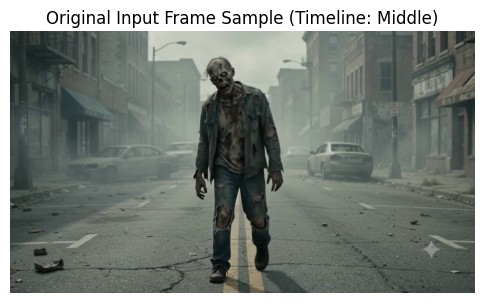


==== [STAGE 2] SAM2 전처리 누끼 완료 프레임 데이터 검증 ====
• 누끼 완료 폴더 경로: /content/drive/MyDrive/zombie_project/zombie_output3_pngs
• 배경 전처리 완료된 PNG 프레임 총 개수: 69개


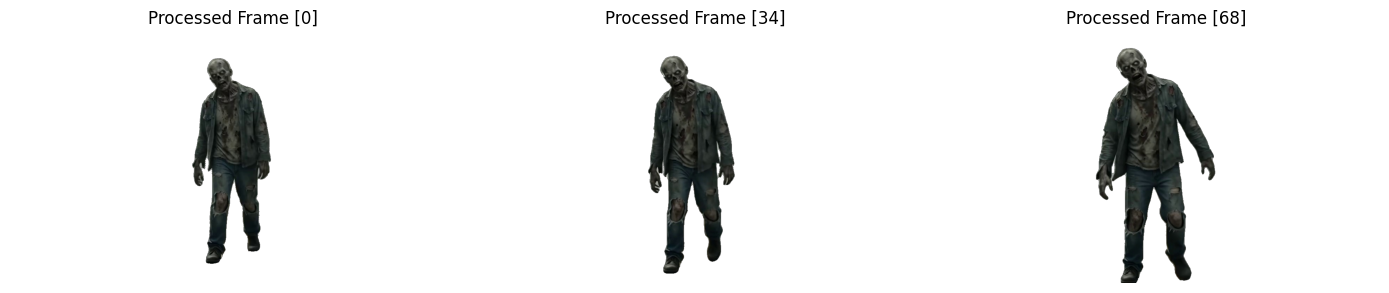


==== [STAGE 3] 최종 누끼 완료된 좀비 객체 비디오 인라인 재생 ====


In [10]:
import os
import cv2
import glob
import matplotlib.pyplot as plt
from google.colab import drive
from IPython.display import HTML, display
from base64 import b64encode

# [1] 구글 드라이브 마운트 확인 및 연결
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# [2] 사용자 지정 경로 정의
video_path = "/content/drive/MyDrive/zombie_project/zombie_sample1.mp4"
save_dir = "/content/drive/MyDrive/zombie_project/zombie_output3_pngs"
video_output_path = "/content/drive/MyDrive/zombie_project/zombie_isolated2.mp4"

# =======================================================================
# STAGE 1: 입력 원본 영상 상태 분석 및 샘플 프레임 추출
# =======================================================================
print("==== [STAGE 1] 입력 원본 영상 메타데이터 및 샘플 분석 ====")
if os.path.exists(video_path):
    cap = cv2.VideoCapture(video_path)
    length = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    print(f"• 원본 영상 파일 경로: {video_path}")
    print(f"• 해상도: {width}x{height} | FPS: {fps:.2f} | 총 프레임 수: {length} frames")

    # 영상의 딱 중간 지점(Middle) 프레임 1개 샘플 추출
    cap.set(cv2.CAP_PROP_POS_FRAMES, length // 2)
    ret, frame = cap.read()
    if ret:
        plt.figure(figsize=(6, 3.5))
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        plt.title("Original Input Frame Sample (Timeline: Middle)")
        plt.axis('off')
        plt.show()
    cap.release()
else:
    print(f"[오류] 입력 영상을 찾을 수 없습니다. 경로를 확인하세요: {video_path}")

# =======================================================================
# STAGE 2: SAM2 누끼 전처리 완료된 개별 프레임 검증 (시작, 중간, 끝)
# =======================================================================
print("\n==== [STAGE 2] SAM2 전처리 누끼 완료 프레임 데이터 검증 ====")
if os.path.exists(save_dir):
    png_files = sorted(glob.glob(os.path.join(save_dir, "*.png")))
    print(f"• 누끼 완료 폴더 경로: {save_dir}")
    print(f"• 배경 전처리 완료된 PNG 프레임 총 개수: {len(png_files)}개")

    if len(png_files) >= 3:
        # 균등 간격으로 3개의 타임라인(처음, 중간, 끝) 샘플 선정
        indices = [0, len(png_files) // 2, len(png_files) - 1]
        fig, axes = plt.subplots(1, 3, figsize=(14, 4))

        for idx, ax in zip(indices, axes):
            img = cv2.imread(png_files[idx], cv2.IMREAD_UNCHANGED)
            if img is not None:
                # 4채널(Alpha투명도 포함) 유무에 따른 색상 변환 처리
                if img.shape[2] == 4:
                    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGRA2RGBA))
                else:
                    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
                ax.set_title(f"Processed Frame [{idx}]")
            ax.axis('off')
        plt.tight_layout()
        plt.show()
else:
    print(f"[오류] 누끼 프레임 저장 폴더를 찾을 수 없습니다: {save_dir}")

# =======================================================================
# STAGE 3: 최종 배경이 제거된 움직이는 좀비 객체 비디오 재생
# =======================================================================
print("\n==== [STAGE 3] 최종 누끼 완료된 좀비 객체 비디오 인라인 재생 ====")
if os.path.exists(video_output_path):
    # 코랩 내 HTML5 <video> 태그 스트리밍을 위한 Base64 인코딩 기법 적용
    mp4_file = open(video_output_path, 'rb').read()
    data_url = "data:video/mp4;base64," + b64encode(mp4_file).decode()

    video_html = f"""
    <div style="text-align: center; background: #1a1a1a; padding: 15px; border-radius: 8px; max-width: 640px; margin: 10px auto;">
        <h4 style="color: #00ffcc; margin-top: 0; font-family: sans-serif;">🎬 최종 결과물: Isolated Zombie Object</h4>
        <video controls width="100%" style="border: 2px solid #333; border-radius: 4px; background-color: #000;">
            <source src="{data_url}" type="video/mp4">
            사용 중인 브라우저가 HTML5 비디오 태그 재생을 지원하지 않습니다.
        </video>
        <p style="color: #888; font-size: 11px; margin-bottom: 0; margin-top: 8px;">
            * 구글 코랩 내에서 배경이 투명/블랙 처리된 좀비 객체의 움직임을 즉시 확인 및 시연할 수 있습니다.
        </p>
    </div>
    """
    display(HTML(video_html))
else:
    print(f"[경고] 최종 출력 비디오 파일을 찾을 수 없습니다: {video_output_path}")